## Radial Basis Functions revisted!

The modern implementation of RBFs accoutns for the *global* trend of the data through a polynomial least squares fit alongside normal RBFs for local features.

$$ \begin{align}
y(x) &= \sum_i^N \omega_i \varphi_i(\|x-x_i\|) + \sum_i^N P_i(x_i) b_i
\end{align} $$

Where $P_i$ is an order $n\lt m$ polynomial. The Numpy RBFInterpolator object fits this equation to:

$$ \begin{align}
[\Phi(x_i, x_j) -\lambda I]\omega +P(x_i) b &= y_i \\
P(x_i)^T \omega &=0
\end{align} $$

where $\lambda = 0$ recovers an exact fit and $\lambda \gt 0$ effecitvely shifts the fitting of the $x_i=x_j$ terms to the bestfit polynomial.

#### Example: Toy gaussian over a quadratic

In [ ]:
#Sampled gaussian

import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
  return np.exp(-(x/2)**2)+.1*x**2

# Create x values for plotting
x_toy = np.linspace(-6, 6, 100)
y_toy = f(x_toy)

# Sample 11 times at 1-interval intervals
x_d = np.arange(-5, 6, 1)
y_d = f(x_d)

11


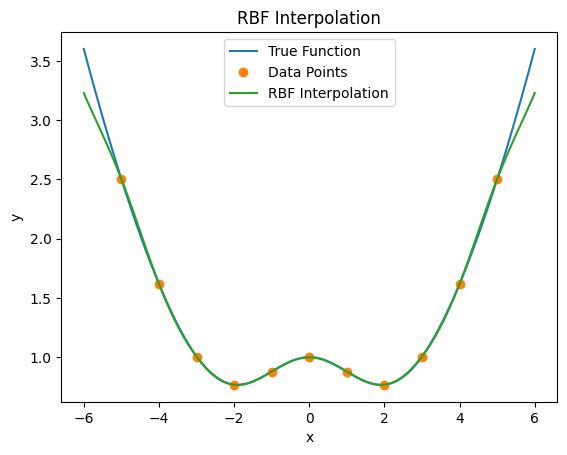

In [ ]:
# prompt: Use a numpy scipy.interpolate.RBFInterpolator over x_d and y_d and plot the result against the true function

import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator

# Create an RBFInterpolator object
print(len(np.array([y_d]).T))
rbf = RBFInterpolator(np.array([x_d]).T, y_d.T, kernel='gaussian', epsilon=1, degree=2)

# Interpolate at the x_toy values
y_rbf = rbf(np.array([x_toy]).T)

# Plot the results
plt.plot(x_toy, y_toy, label='True Function')
plt.plot(x_d, y_d, 'o', label='Data Points')
plt.plot(x_toy, y_rbf, label='RBF Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('RBF Interpolation')
plt.show()


In [4]:
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import RBFInterpolator

# Define the target function
def f(x, y):
    return np.exp(-.5*x**2 - .2*y**2) * np.sin(x) * np.cos(.5*y)

x_grid_vals = np.linspace(-3, 3, 100)
y_grid_vals = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_grid_vals, y_grid_vals)
Z_true = f(X, Y)

num_samples = 100
x_samples = np.random.uniform(-3, 3, num_samples)
y_samples = np.random.uniform(-3, 3, num_samples)
z_samples = f(x_samples, y_samples)

# Prepare sample points for RBFInterpolator
sample_points = np.column_stack((x_samples, y_samples))

dist_matrix = np.sqrt((x_samples[:, np.newaxis] - x_samples)**2 + (y_samples[:, np.newaxis] - y_samples)**2)
average_distance = np.mean(dist_matrix)
eps = 1 / average_distance

# Fit RBF interpolator (using Gaussian kernel, can adjust epsilon and degree as needed)
rbf = RBFInterpolator(sample_points, z_samples, kernel='gaussian', epsilon=1, degree=1)

# Evaluate on grid
grid_points = np.column_stack((X.ravel(), Y.ravel()))
Z_fit = rbf(grid_points).reshape(X.shape)

surface_true = go.Surface(x=X, y=Y, z=Z_true, colorscale='Blues', showscale=False, name='Original')
surface_fit = go.Surface(x=X, y=Y, z=Z_fit, colorscale='Viridis', showscale=False, name='RBF Fit')
scatter_samples = go.Scatter3d(
    x=x_samples, y=y_samples, z=z_samples,
    mode='markers', marker=dict(color='red', size=3), name='Samples'
 )

# Plot 1: Original Function
fig_original = go.Figure(data=[surface_true, scatter_samples])
fig_original.update_layout(
    title='Original Function and Data Samples',
    scene=dict(
        xaxis_title='x', yaxis_title='y', zaxis_title='z',
        zaxis=dict(range=[-.7, .7]),
        aspectratio=dict(x=1, y=1, z=0.5)
    )
)
print("Displaying the original function...")
fig_original.show()

# Plot 2: RBF Interpolation
fig_fit = go.Figure(data=[surface_fit, scatter_samples])
fig_fit.update_layout(
    title='RBF Interpolated Fit and Data Samples',
    scene=dict(
        xaxis_title='x', yaxis_title='y', zaxis_title='z',
        zaxis=dict(range=[-.7, .7]),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.5)
    )
)
print("Displaying the RBF fitted function...")
fig_fit.show()

Displaying the original function...


Displaying the RBF fitted function...
